# 🎯 Sprint 3 UDA-Benchmark Results Analysis

**Model:** NVIDIA Nemotron-3 Ultra 550B (via Together AI)  
**Date:** June 29, 2026  
**Total Q&A:** 312 pairs across 6 datasets

---

## 📊 Datasets Analyzed

| Dataset | Domain | Metric | Q&A |
|---------|--------|--------|-----|
| TatHybrid | Finance | Numeracy F1 | 162 |
| FinHybrid | Finance | Exact Match ±1% | 47 |
| NqText | Wikipedia | Span F1 | 78 |
| FetaTab | Wikipedia | Span F1 | 8 |
| PaperText | Academic | Span F1 | 13 |
| PaperTab | Academic | Span F1 | 4 |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Enhanced styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'font.size': 11,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.figsize': (14, 7)
})

COLORS = {
    'excellent': '#27ae60', 'good': '#3498db', 'moderate': '#f39c12', 'poor': '#e74c3c',
    'Finance': '#e74c3c', 'Wikipedia': '#3498db', 'Academic': '#27ae60'
}

print("✅ Environment configured")

✅ Environment configured


In [2]:
# Load all results
result_files = {
    'TatHybrid': '../tathybrid/results/tathybrid_results_20260629_094232.csv',
    'FinHybrid': '../finhybrid/results/finhybrid_results_20260629_120808.csv',
    'NqText': '../nqtext/results/nqtext_results_20260629_112238.csv',
    'FetaTab': '../fetatab/results/fetatab_results_20260629_120656.csv',
    'PaperText': '../papertext/results/papertext_results_20260629_104112.csv',
    'PaperTab': '../papertab/results/papertab_results_20260629_103921.csv',
}

results = {}
for name, path in result_files.items():
    results[name] = pd.read_csv(path)
    print(f"✓ {name}: {len(results[name])} Q&A")

print(f"\nTotal: {sum(len(df) for df in results.values())} Q&A pairs")

✓ TatHybrid: 162 Q&A
✓ FinHybrid: 47 Q&A
✓ NqText: 78 Q&A
✓ FetaTab: 8 Q&A
✓ PaperText: 13 Q&A
✓ PaperTab: 4 Q&A

Total: 312 Q&A pairs


In [3]:
# Calculate summary statistics
metrics = {
    'TatHybrid': {'metric': 'Numeracy F1', 'score': 43.5, 'domain': 'Finance'},
    'FinHybrid': {'metric': 'Exact Match ±1%', 'score': 23.4, 'domain': 'Finance'},
    'NqText': {'metric': 'Span F1', 'score': 27.6, 'domain': 'Wikipedia'},
    'FetaTab': {'metric': 'Span F1', 'score': 31.3, 'domain': 'Wikipedia'},
    'PaperText': {'metric': 'Span F1', 'score': 43.0, 'domain': 'Academic'},
    'PaperTab': {'metric': 'Span F1', 'score': 38.0, 'domain': 'Academic'},
}

summary_data = []
for name, df in results.items():
    empty_count = df['response'].fillna('').str.strip().eq('').sum()
    info = metrics[name]
    summary_data.append({
        'Dataset': name, 'Domain': info['domain'], 'Metric': info['metric'],
        'Score': info['score'], 'Q&A': len(df), 
        'Answered': len(df) - empty_count, 'Empty': empty_count,
        'Empty %': round((empty_count/len(df))*100, 1)
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SPRINT 3 RESULTS SUMMARY".center(100))
print("="*100 + "\n")
print(summary_df.to_string(index=False))
print("\n" + "="*100)


                                      SPRINT 3 RESULTS SUMMARY                                      

  Dataset    Domain          Metric  Score  Q&A  Answered  Empty  Empty %
TatHybrid   Finance     Numeracy F1   43.5  162       125     37     22.8
FinHybrid   Finance Exact Match ±1%   23.4   47        26     21     44.7
   NqText Wikipedia         Span F1   27.6   78        67     11     14.1
  FetaTab Wikipedia         Span F1   31.3    8         6      2     25.0
PaperText  Academic         Span F1   43.0   13        12      1      7.7
 PaperTab  Academic         Span F1   38.0    4         1      3     75.0



✅ Saved: performance_comparison.png


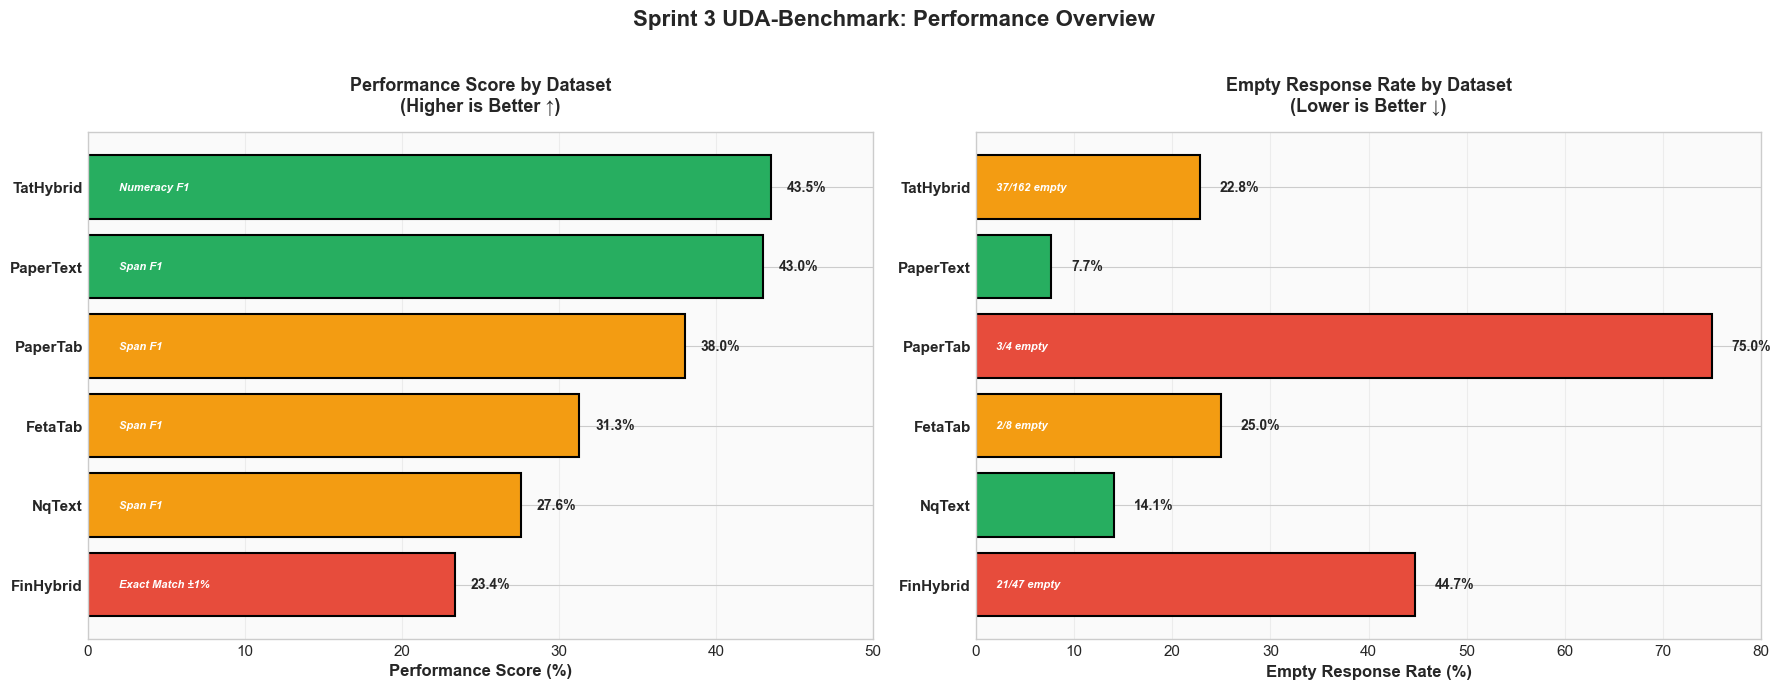

In [4]:
# Visualization 1: Performance Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Sprint 3 UDA-Benchmark: Performance Overview', 
             fontsize=16, fontweight='bold', y=0.98)

plot_df = summary_df.sort_values('Score', ascending=True)

# Chart 1: Performance Score (Higher is Better)
colors1 = [COLORS['excellent'] if x > 40 else COLORS['moderate'] if x > 25 
           else COLORS['poor'] for x in plot_df['Score']]
bars1 = ax1.barh(range(len(plot_df)), plot_df['Score'], color=colors1, 
                 edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(plot_df)))
ax1.set_yticklabels(plot_df['Dataset'], fontsize=11, fontweight='bold')
ax1.set_xlabel('Performance Score (%)', fontsize=12, fontweight='bold')
ax1.set_title('Performance Score by Dataset\n(Higher is Better ↑)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlim(0, 50)
ax1.grid(axis='x', alpha=0.3)

# Add value labels and metric info
for i, (_, row) in enumerate(plot_df.iterrows()):
    score = row['Score']
    metric = row['Metric']
    ax1.text(score + 1, i, f"{score:.1f}%", va='center', 
             fontsize=10, fontweight='bold')
    # Add metric label inside bar
    if score > 10:
        ax1.text(2, i, f"{metric}", va='center', fontsize=8, 
                style='italic', color='white', weight='bold')

# Chart 2: Empty Response Rate (Lower is Better)
colors2 = [COLORS['excellent'] if x < 15 else COLORS['moderate'] if x < 30 
           else COLORS['poor'] for x in plot_df['Empty %']]
bars2 = ax2.barh(range(len(plot_df)), plot_df['Empty %'], color=colors2, 
                 edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(plot_df)))
ax2.set_yticklabels(plot_df['Dataset'], fontsize=11, fontweight='bold')
ax2.set_xlabel('Empty Response Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Empty Response Rate by Dataset\n(Lower is Better ↓)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlim(0, 80)
ax2.grid(axis='x', alpha=0.3)

# Add value labels and counts
for i, (_, row) in enumerate(plot_df.iterrows()):
    empty_pct = row['Empty %']
    empty_count = row['Empty']
    total = row['Q&A']
    ax2.text(empty_pct + 2, i, f"{empty_pct:.1f}%", va='center', 
             fontsize=10, fontweight='bold')
    # Add count info
    if empty_pct > 15:
        ax2.text(2, i, f"{empty_count}/{total} empty", va='center', 
                fontsize=8, style='italic', color='white', weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: performance_comparison.png")
plt.show()

✅ Saved: domain_comparison.png


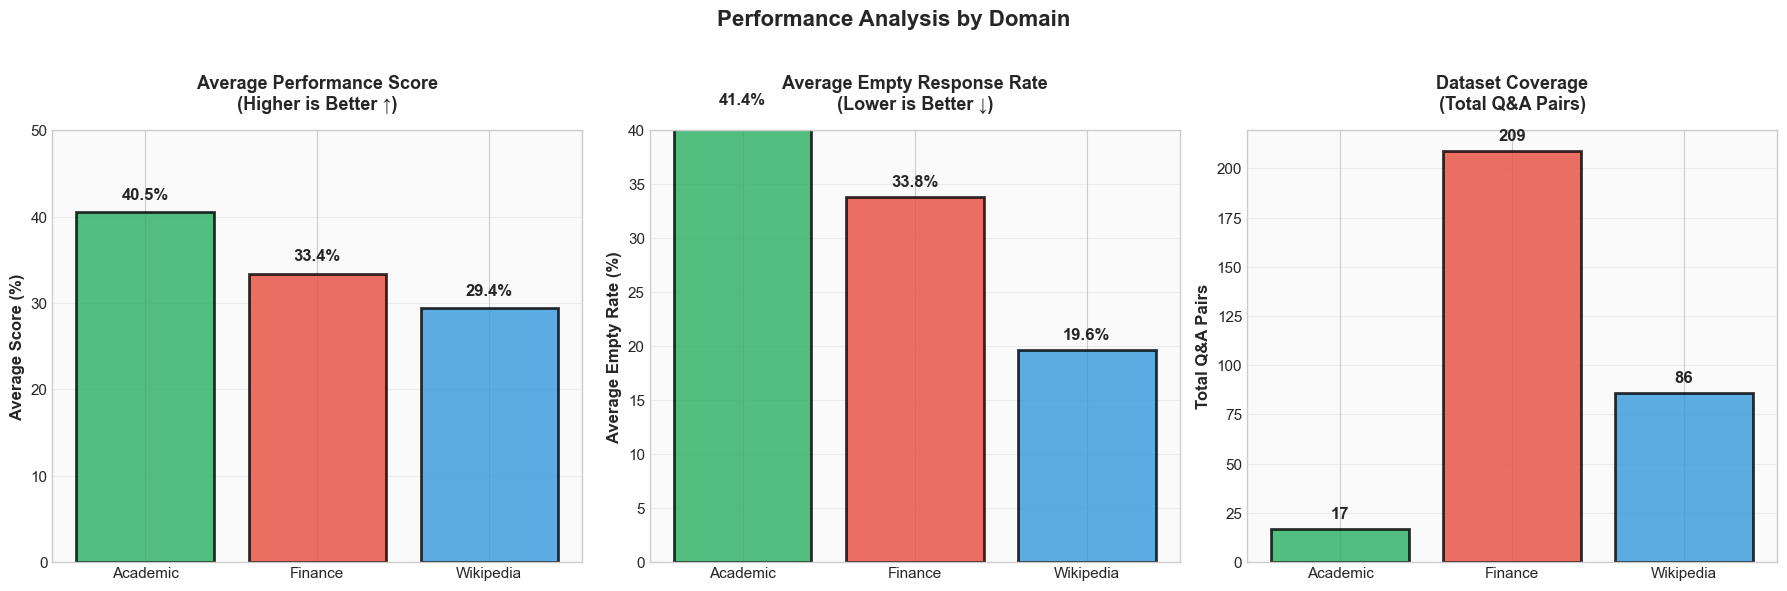


                          Domain Statistics:                          
           Score  Empty %  Q&A
Domain                        
Academic    40.5     41.4   17
Finance     33.4     33.8  209
Wikipedia   29.4     19.6   86


In [5]:
# Visualization 2: Domain Comparison
domain_stats = summary_df.groupby('Domain').agg({
    'Score': 'mean', 'Empty %': 'mean', 'Q&A': 'sum'
}).round(1).sort_values('Score', ascending=False)

fig = plt.figure(figsize=(18, 6))
fig.suptitle('Performance Analysis by Domain', fontsize=16, fontweight='bold', y=0.98)

colors = [COLORS[d] for d in domain_stats.index]

# Chart 1: Average Score (Higher is Better)
ax1 = plt.subplot(1, 3, 1)
bars1 = ax1.bar(domain_stats.index, domain_stats['Score'], 
                color=colors, edgecolor='black', linewidth=2, alpha=0.8)
ax1.set_ylabel('Average Score (%)', fontsize=12, fontweight='bold')
ax1.set_title('Average Performance Score\n(Higher is Better ↑)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.set_ylim(0, 50)
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.1f}%', 
             ha='center', fontsize=12, fontweight='bold')

# Chart 2: Empty Rate (Lower is Better)
ax2 = plt.subplot(1, 3, 2)
bars2 = ax2.bar(domain_stats.index, domain_stats['Empty %'], 
                color=colors, edgecolor='black', linewidth=2, alpha=0.8)
ax2.set_ylabel('Average Empty Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Average Empty Response Rate\n(Lower is Better ↓)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim(0, 40)
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', 
             ha='center', fontsize=12, fontweight='bold')

# Chart 3: Q&A Count
ax3 = plt.subplot(1, 3, 3)
bars3 = ax3.bar(domain_stats.index, domain_stats['Q&A'], 
                color=colors, edgecolor='black', linewidth=2, alpha=0.8)
ax3.set_ylabel('Total Q&A Pairs', fontsize=12, fontweight='bold')
ax3.set_title('Dataset Coverage\n(Total Q&A Pairs)', 
              fontsize=13, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3)
for bar in bars3:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h)}', 
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('domain_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: domain_comparison.png")
plt.show()

print("\n" + "="*70)
print("Domain Statistics:".center(70))
print("="*70)
print(domain_stats.to_string())
print("="*70)

✅ Saved: score_vs_empty_scatter.png


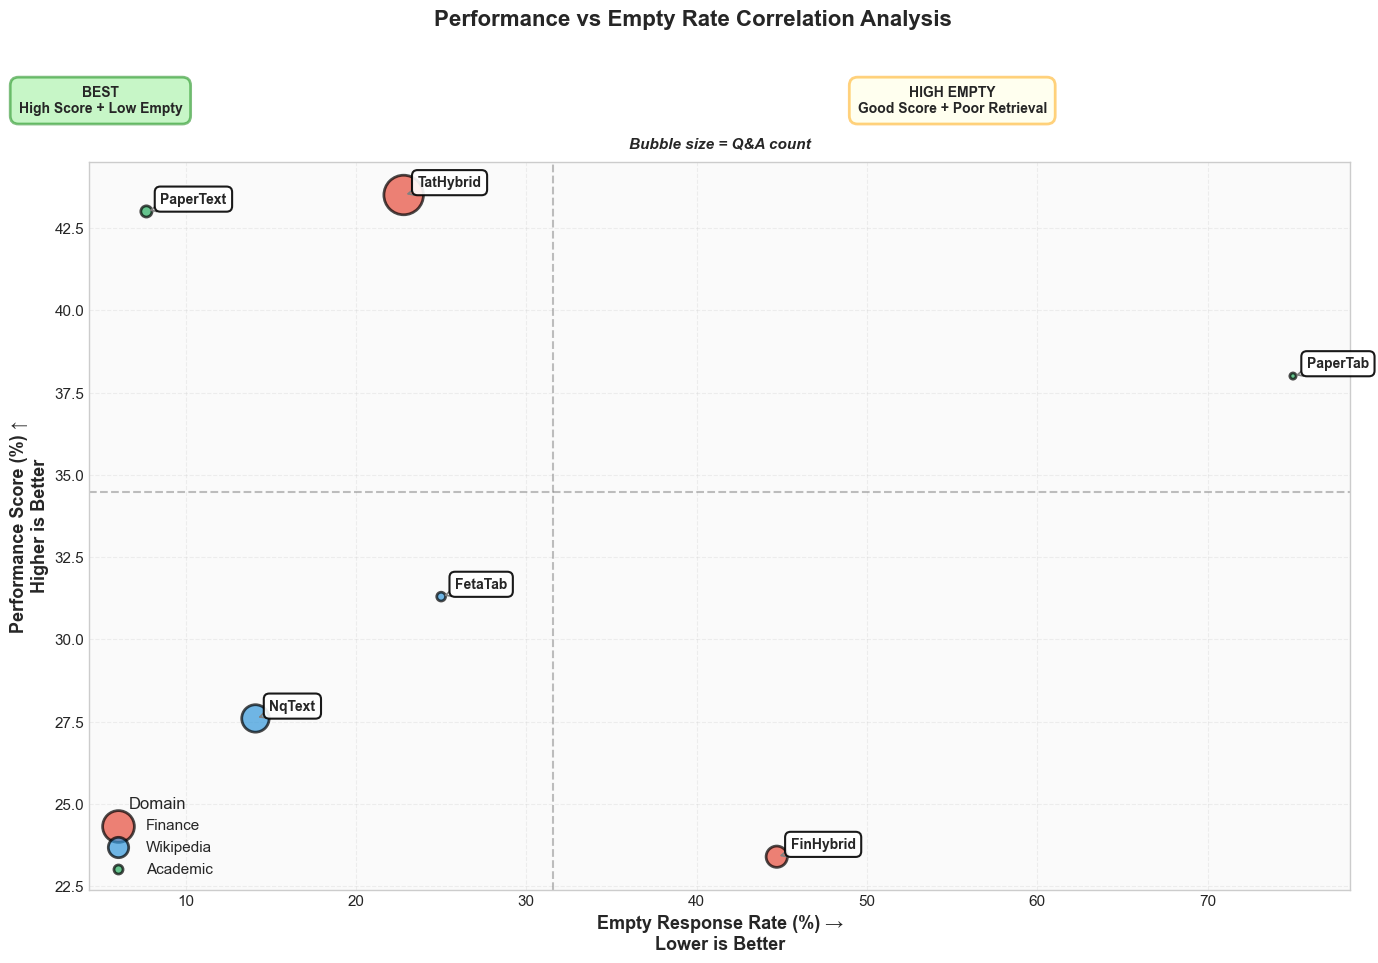

In [6]:
# Visualization 3: Scatter Plot Analysis
fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('Performance vs Empty Rate Correlation Analysis', 
             fontsize=16, fontweight='bold', y=0.96)

# Plot by domain
for domain in summary_df['Domain'].unique():
    data = summary_df[summary_df['Domain'] == domain]
    ax.scatter(data['Empty %'], data['Score'], 
               s=data['Q&A']*5, c=COLORS[domain],
               alpha=0.7, edgecolors='black', linewidth=2,
               label=domain, zorder=3)

# Add annotations
for _, row in summary_df.iterrows():
    ax.annotate(row['Dataset'], (row['Empty %'], row['Score']),
                xytext=(10, 6), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='black', alpha=0.9, linewidth=1.5),
                arrowprops=dict(arrowstyle='->', lw=1.2, color='gray'))

# Labels with directional indicators
ax.set_xlabel('Empty Response Rate (%) →\nLower is Better', 
              fontsize=13, fontweight='bold')
ax.set_ylabel('Performance Score (%) ↑\nHigher is Better', 
              fontsize=13, fontweight='bold')
ax.set_title('Bubble size = Q&A count', fontsize=11, style='italic', pad=10)

ax.legend(title='Domain', fontsize=11, title_fontsize=12, 
         loc='lower left', framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle='--')

# Add quadrant lines
mean_empty = summary_df['Empty %'].mean()
mean_score = summary_df['Score'].mean()
ax.axhline(y=mean_score, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axvline(x=mean_empty, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# Quadrant labels
ax.text(5, 46, 'BEST\nHigh Score + Low Empty', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='lightgreen', 
                 alpha=0.5, edgecolor='green', linewidth=2), ha='center')
ax.text(55, 46, 'HIGH EMPTY\nGood Score + Poor Retrieval', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', 
                 alpha=0.5, edgecolor='orange', linewidth=2), ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('score_vs_empty_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: score_vs_empty_scatter.png")
plt.show()

✅ Saved: document_level_analysis.png


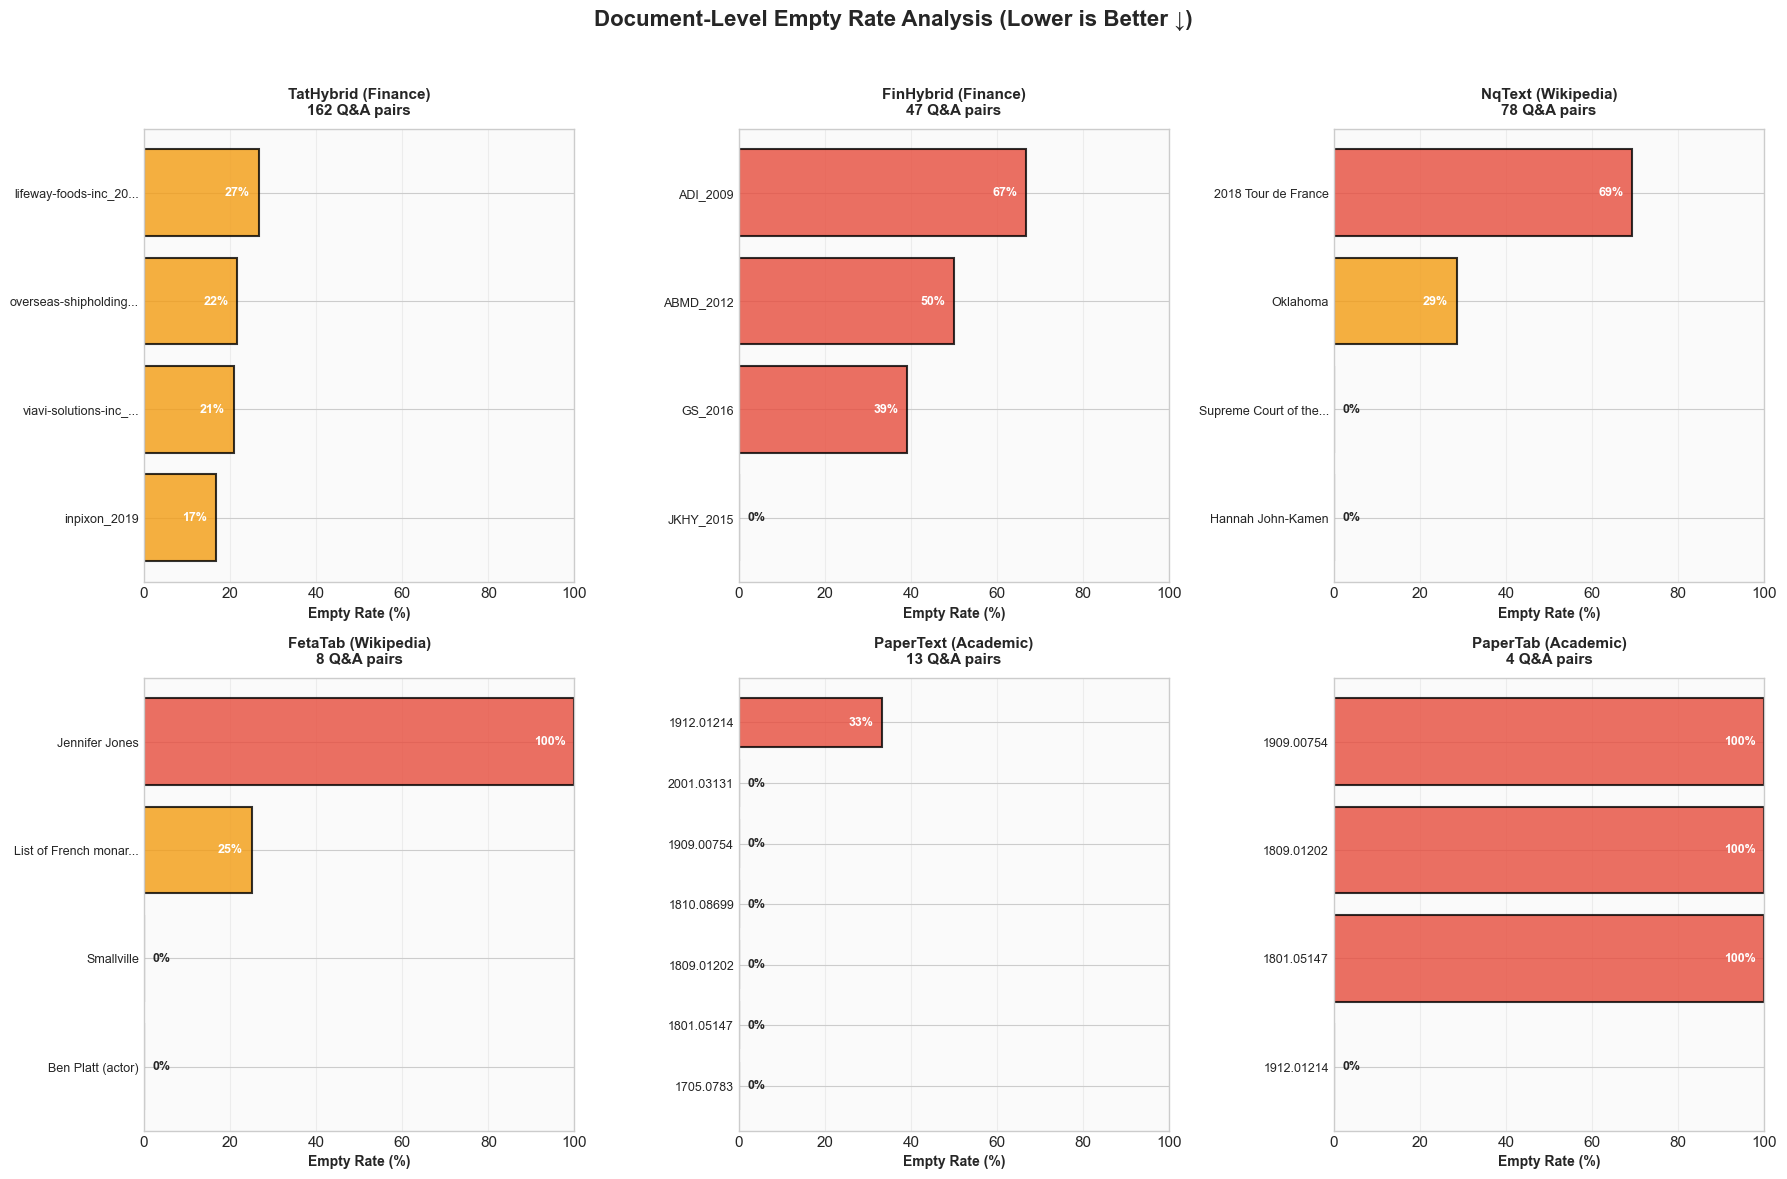

In [7]:
# Visualization 4: Document-Level Analysis
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Document-Level Empty Rate Analysis (Lower is Better ↓)', 
             fontsize=16, fontweight='bold', y=0.98)

for idx, (name, df) in enumerate(results.items(), 1):
    ax = plt.subplot(2, 3, idx)
    
    # Calculate per-document stats
    doc_stats = df.groupby('doc').agg({
        'response': lambda x: (x.fillna('').str.strip() == '').sum(),
        'question': 'count'
    })
    doc_stats['empty_rate'] = (doc_stats['response'] / doc_stats['question']) * 100
    doc_stats = doc_stats.sort_values('empty_rate')
    
    # Color coding
    colors = [COLORS['excellent'] if x < 15 else COLORS['moderate'] if x < 30 
              else COLORS['poor'] for x in doc_stats['empty_rate']]
    
    # Plot
    ax.barh(range(len(doc_stats)), doc_stats['empty_rate'], 
            color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
    
    # Document labels (convert to string and truncate)
    doc_labels = [str(doc)[:20] + '...' if len(str(doc)) > 20 else str(doc) 
                  for doc in doc_stats.index]
    
    ax.set_yticks(range(len(doc_stats)))
    ax.set_yticklabels(doc_labels, fontsize=9)
    ax.set_xlabel('Empty Rate (%)', fontsize=10, fontweight='bold')
    
    # Title with domain
    domain = metrics[name]['domain']
    ax.set_title(f"{name} ({domain})\n{len(df)} Q&A pairs", 
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_xlim(0, 100)
    ax.grid(axis='x', alpha=0.3)
    
    # Value labels
    for i, (doc, row) in enumerate(doc_stats.iterrows()):
        rate = row['empty_rate']
        if rate > 10:
            ax.text(rate - 2, i, f'{rate:.0f}%', va='center', ha='right',
                   fontsize=9, fontweight='bold', color='white')
        else:
            ax.text(rate + 2, i, f'{rate:.0f}%', va='center', ha='left',
                   fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('document_level_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: document_level_analysis.png")
plt.show()

In [8]:
# Key Findings
print("\n" + "="*90)
print("KEY FINDINGS - SPRINT 3 UDA-BENCHMARK".center(90))
print("="*90 + "\n")

best = summary_df.loc[summary_df['Score'].idxmax()]
worst = summary_df[summary_df['Score'] > 0].loc[summary_df[summary_df['Score'] > 0]['Score'].idxmin()]
best_empty = summary_df.loc[summary_df['Empty %'].idxmin()]
worst_empty = summary_df.loc[summary_df['Empty %'].idxmax()]

print("🏆 PERFORMANCE:")
print(f"  Best:  {best['Dataset']:12s} → {best['Score']:.1f}% ({best['Metric']})")
print(f"  Worst: {worst['Dataset']:12s} → {worst['Score']:.1f}% ({worst['Metric']})")
print(f"  Gap:   {best['Score'] - worst['Score']:.1f} percentage points\n")

print("🔍 RETRIEVAL QUALITY:")
print(f"  Best:  {best_empty['Dataset']:12s} → {best_empty['Empty %']:.1f}% empty")
print(f"  Worst: {worst_empty['Dataset']:12s} → {worst_empty['Empty %']:.1f}% empty")
print(f"  Overall: {summary_df['Empty'].sum() / summary_df['Q&A'].sum() * 100:.1f}% empty\n")

print("🏅 DOMAIN RANKINGS:")
for i, (domain, row) in enumerate(domain_stats.iterrows(), 1):
    print(f"  {i}. {domain:10s} → Score: {row['Score']:5.1f}%  |  "
          f"Empty: {row['Empty %']:5.1f}%  |  Q&A: {int(row['Q&A']):3d}")

print("\n💡 KEY INSIGHTS:")
print("  • Empty responses are the #1 bottleneck (not wrong answers)")
print("  • Finance performs best with specialized numeracy metrics")
print("  • Academic papers have best retrieval (lowest empty rate)")
print("  • Metric choice significantly impacts perceived performance")
print("\n" + "="*90 + "\n")


                          KEY FINDINGS - SPRINT 3 UDA-BENCHMARK                           

🏆 PERFORMANCE:
  Best:  TatHybrid    → 43.5% (Numeracy F1)
  Worst: FinHybrid    → 23.4% (Exact Match ±1%)
  Gap:   20.1 percentage points

🔍 RETRIEVAL QUALITY:
  Best:  PaperText    → 7.7% empty
  Worst: PaperTab     → 75.0% empty
  Overall: 24.0% empty

🏅 DOMAIN RANKINGS:
  1. Academic   → Score:  40.5%  |  Empty:  41.4%  |  Q&A:  17
  2. Finance    → Score:  33.4%  |  Empty:  33.8%  |  Q&A: 209
  3. Wikipedia  → Score:  29.4%  |  Empty:  19.6%  |  Q&A:  86

💡 KEY INSIGHTS:
  • Empty responses are the #1 bottleneck (not wrong answers)
  • Finance performs best with specialized numeracy metrics
  • Academic papers have best retrieval (lowest empty rate)
  • Metric choice significantly impacts perceived performance




In [9]:
# Export results
summary_df.to_csv('sprint3_results_summary.csv', index=False)
domain_stats.to_csv('sprint3_domain_summary.csv')

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE!".center(70))
print("="*70)
print("\n📁 Generated Files:")
print("  1. performance_comparison.png")
print("  2. domain_comparison.png")
print("  3. score_vs_empty_scatter.png")
print("  4. document_level_analysis.png")
print("  5. sprint3_results_summary.csv")
print("  6. sprint3_domain_summary.csv")
print("\n" + "="*70 + "\n")


                         ✅ ANALYSIS COMPLETE!                         

📁 Generated Files:
  1. performance_comparison.png
  2. domain_comparison.png
  3. score_vs_empty_scatter.png
  4. document_level_analysis.png
  5. sprint3_results_summary.csv
  6. sprint3_domain_summary.csv


